In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision
import time
from torchvision import transforms
from torch.utils.data import DataLoader

torch.manual_seed(42)
if torch.backends.mps.is_available():
    device = "mps"
elif torch.cuda.is_available():
    device = "cuda"
else:
    device = "cpu"

In [2]:
transforms_f = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
     ])
training_set = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=transforms_f)
test_set  = torchvision.datasets.CIFAR10(root='./data', train=False, transform=transforms_f)

In [3]:
batch_size = 32
training_loader = DataLoader(training_set, batch_size=batch_size, shuffle=True, num_workers=3)
test_loader = DataLoader(test_set, batch_size=batch_size, shuffle=False, num_workers=3)

In [4]:
class CustomCNN(nn.Module):
    def __init__(self, in_channels=3, kernel_size=3 ):
        super(CustomCNN, self).__init__()
        padding = (kernel_size - 1) // 2

        self.conv1 = nn.Conv2d(in_channels, 16, kernel_size=kernel_size, padding=padding)
        self.conv2 = nn.Conv2d(16, 32, kernel_size=kernel_size, padding=padding)
        self.conv3 = nn.Conv2d(32, 64, kernel_size=kernel_size, padding=padding)
        self.conv4 = nn.Conv2d(64, 128, kernel_size=kernel_size, padding=padding)

        self.gap = nn.AdaptiveAvgPool2d(1)  # Output: (batch_size, 128, 1, 1)


        self.fc = nn.Linear(128, 10)

    def forward(self, x):
        x = F.relu(self.conv1(x))

        x = F.relu(self.conv2(x))

        x = F.relu(self.conv3(x))

        x = F.relu(self.conv4(x))

        x = self.gap(x)
        x = x.reshape(x.size(0), -1)
        x = self.fc(x)

        return x

In [5]:
class CustomDWPWCNN(nn.Module):
    def __init__(self, in_channels=3, kernel_size=3 ):
        super(CustomDWPWCNN, self).__init__()
        padding = (kernel_size - 1) // 2

        self.conv1 = nn.Conv2d(in_channels, 16, kernel_size=kernel_size, padding=padding)
        self.conv2 = nn.Conv2d(16, 32, kernel_size=kernel_size, padding=padding)

        self.conv3_dw = nn.Conv2d(32, 32, kernel_size=kernel_size, padding=padding, groups=32)
        self.conv3_pw = nn.Conv2d(32, 64, kernel_size=1, padding=0)

        self.conv4_dw = nn.Conv2d(64, 64, kernel_size=kernel_size, padding=padding, groups=64)
        self.conv4_pw = nn.Conv2d(64, 128, kernel_size=1, padding=0)

        self.gap = nn.AdaptiveAvgPool2d(1)  # Output: (batch_size, 128, 1, 1)

        self.fc = nn.Linear(128, 10)

    def forward(self, x):
        x = F.relu(self.conv1(x))

        x = F.relu(self.conv2(x))

        x = F.relu(self.conv3_dw(x))
        x = F.relu(self.conv3_pw(x))

        x = F.relu(self.conv4_dw(x))
        x = F.relu(self.conv4_pw(x))

        x = self.gap(x)
        x = x.reshape(x.size(0), -1)
        x = self.fc(x)
        return x

In [6]:
def train_and_compare():
    standard_model = CustomCNN().to(device)
    dwpw_model = CustomDWPWCNN().to(device)

    loss_fn = nn.CrossEntropyLoss()

    # Same optimizers
    opt_std = torch.optim.Adam(standard_model.parameters(), lr=0.001)
    opt_dwpw = torch.optim.Adam(dwpw_model.parameters(), lr=0.001)

    # Track metrics
    std_losses, dwpw_losses = [], []
    std_acc, dwpw_acc = [], []
    std_times, dwpw_times = [], []

    for epoch in range(10):
        # === DWPW Model Training ===
        dwpw_model.train()
        correct_dwpw = 0
        running_loss_dwpw = 0.0  
        
        time_start = time.time()
        total_items = 0
        
        for images, labels in training_loader:
            images, labels = images.to(device), labels.to(device)
            
            opt_dwpw.zero_grad()
            output_dwpw = dwpw_model(images)
            loss_batch = loss_fn(output_dwpw, labels) 
            loss_batch.backward()
            opt_dwpw.step()
            
            running_loss_dwpw += loss_batch.item()  
            
            _, predicted_dwpw = torch.max(output_dwpw, 1)
            correct_dwpw += (predicted_dwpw == labels).sum().item()
            total_items += labels.size(0)  
        
        dwpw_epoch_time = time.time() - time_start
        dwpw_epoch_loss = running_loss_dwpw / len(training_loader)  
        dwpw_epoch_acc = 100 * correct_dwpw / total_items
        
        dwpw_losses.append(dwpw_epoch_loss)        
        dwpw_acc.append(dwpw_epoch_acc)
        dwpw_times.append(dwpw_epoch_time)
        
        print(f"Epoch DWPW: {epoch+1}, Acc: {dwpw_epoch_acc:.2f}%, Loss: {dwpw_epoch_loss:.4f}, Time: {dwpw_epoch_time:.2f}s")
        
        # === Standard Model Training ===
        standard_model.train()
        correct_std = 0
        running_loss_std = 0.0  
        
        time_start = time.time()
        total_items = 0
        
        for images, labels in training_loader:
            images, labels = images.to(device), labels.to(device)
            
            opt_std.zero_grad()
            output_std = standard_model(images)
            loss_batch = loss_fn(output_std, labels) 
            loss_batch.backward()
            opt_std.step()
            
            running_loss_std += loss_batch.item()  
            
            _, predicted_std = torch.max(output_std, 1)
            correct_std += (predicted_std == labels).sum().item()
            total_items += labels.size(0)
        
        std_epoch_time = time.time() - time_start
        std_epoch_loss = running_loss_std / len(training_loader)     
        std_epoch_acc = 100 * correct_std / total_items
        
        std_losses.append(std_epoch_loss)
        std_acc.append(std_epoch_acc)
        std_times.append(std_epoch_time)
        
        print(f"Epoch STD: {epoch+1}, Acc: {std_epoch_acc:.2f}%, Loss: {std_epoch_loss:.4f}, Time: {std_epoch_time:.2f}s")

    return {
        'standard': {'model': standard_model, 'losses': std_losses, 'times': std_times, "acc": std_acc},
        'dwpw': {'model': dwpw_model, 'losses': dwpw_losses, 'times': dwpw_times, "acc": dwpw_acc}
    }

In [7]:
results=train_and_compare()

Epoch DWPW: 1, Acc: 27.30%, Loss: 1.9061, Time: 36.37s
Epoch STD: 1, Acc: 31.33%, Loss: 1.7943, Time: 38.94s
Epoch DWPW: 2, Acc: 40.65%, Loss: 1.6100, Time: 35.46s
Epoch STD: 2, Acc: 44.10%, Loss: 1.5167, Time: 38.99s
Epoch DWPW: 3, Acc: 45.01%, Loss: 1.5063, Time: 36.02s
Epoch STD: 3, Acc: 50.44%, Loss: 1.3730, Time: 38.73s
Epoch DWPW: 4, Acc: 48.29%, Loss: 1.4313, Time: 35.94s
Epoch STD: 4, Acc: 54.07%, Loss: 1.2828, Time: 39.46s
Epoch DWPW: 5, Acc: 51.12%, Loss: 1.3656, Time: 36.52s
Epoch STD: 5, Acc: 56.70%, Loss: 1.2170, Time: 38.59s
Epoch DWPW: 6, Acc: 53.04%, Loss: 1.3169, Time: 35.50s
Epoch STD: 6, Acc: 59.24%, Loss: 1.1560, Time: 39.34s
Epoch DWPW: 7, Acc: 54.79%, Loss: 1.2696, Time: 36.47s
Epoch STD: 7, Acc: 61.11%, Loss: 1.1079, Time: 39.82s
Epoch DWPW: 8, Acc: 56.09%, Loss: 1.2286, Time: 35.96s
Epoch STD: 8, Acc: 62.62%, Loss: 1.0656, Time: 39.71s
Epoch DWPW: 9, Acc: 57.50%, Loss: 1.1965, Time: 36.12s
Epoch STD: 9, Acc: 63.93%, Loss: 1.0303, Time: 39.47s
Epoch DWPW: 10, Acc

🏗️  MODEL ARCHITECTURE COMPARISON
Standard CNN Parameters:    98,730
DWPW CNN Parameters:        17,770
Parameter Reduction:        82.0%

⚡ TRAINING PERFORMANCE COMPARISON
Standard CNN Avg Time:      39.32s per epoch
DWPW CNN Avg Time:          36.04s per epoch
Speed Improvement:          8.3%

🎯 FINAL ACCURACY COMPARISON
Standard CNN Final Acc:     64.81%
DWPW CNN Final Acc:         58.60%
Accuracy Difference:        -6.21%

📉 FINAL LOSS COMPARISON
Standard CNN Final Loss:    1.0001
DWPW CNN Final Loss:        1.1667



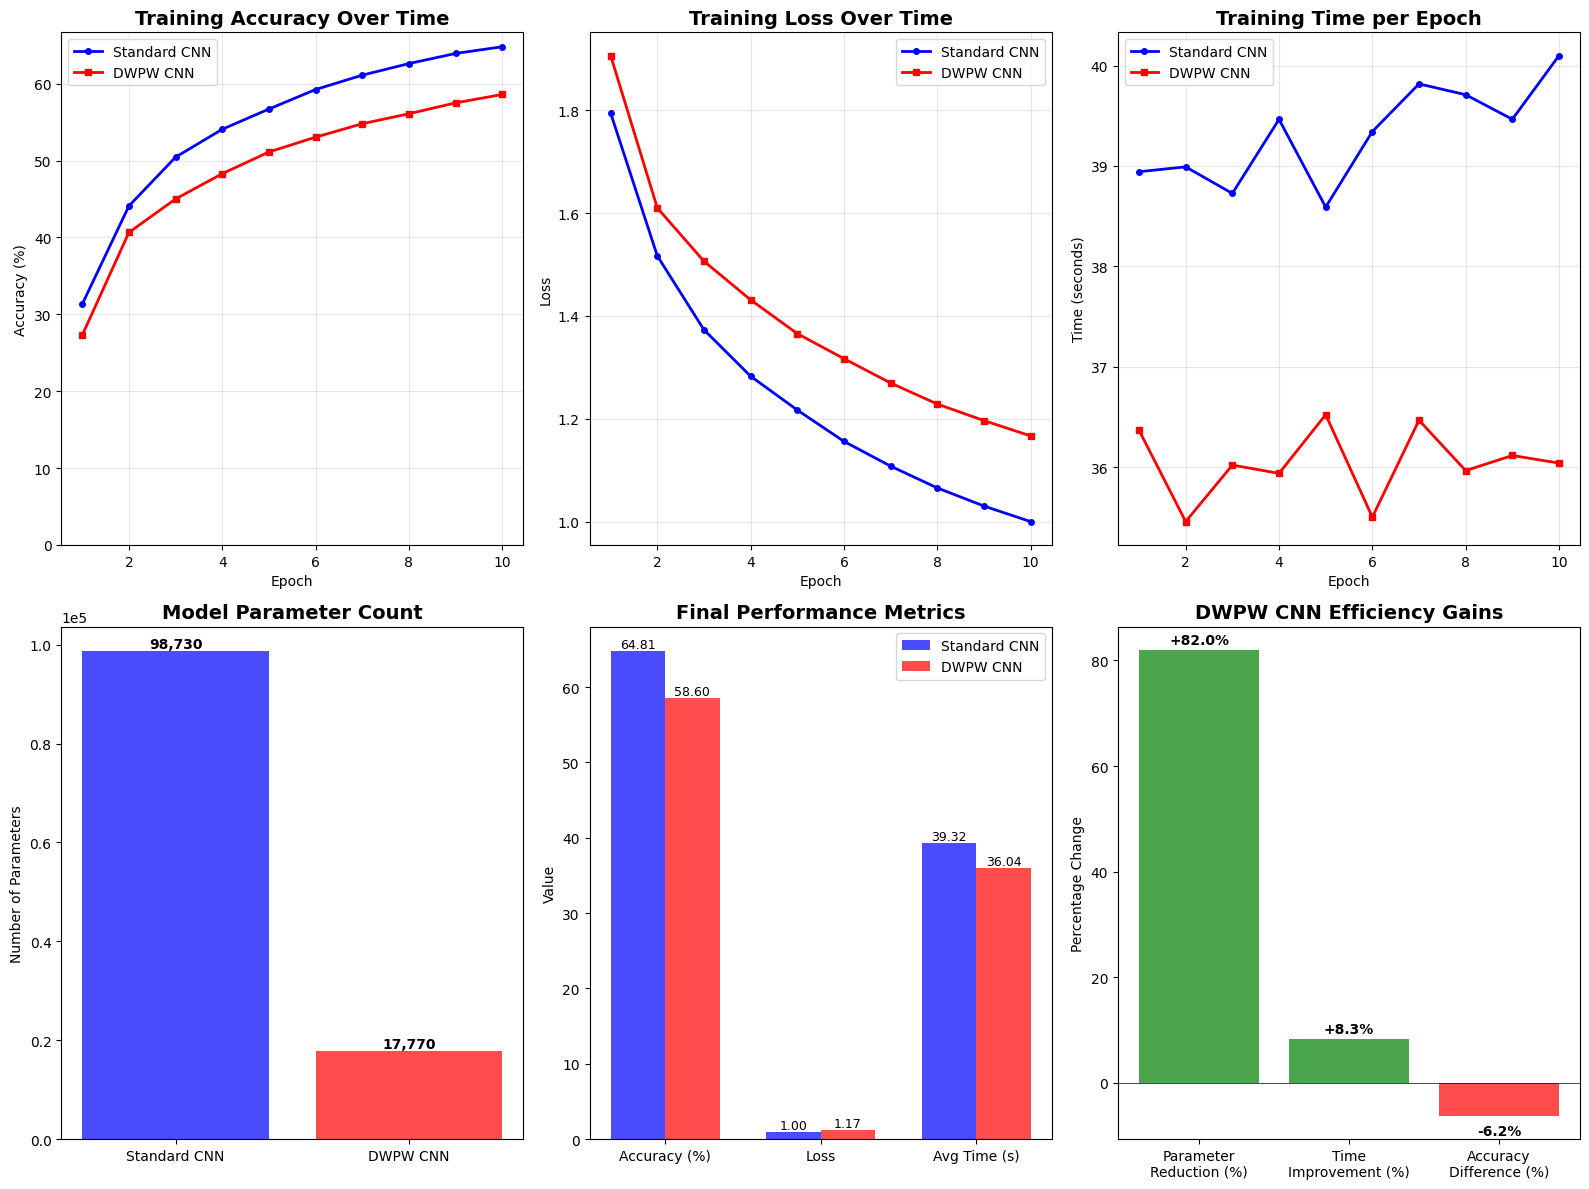

🧪 TEST SET EVALUATION
Standard CNN Test Accuracy:  65.44%
DWPW CNN Test Accuracy:      58.14%
Test Accuracy Difference:    -7.30%


📊 COMPREHENSIVE EXPERIMENT SUMMARY REPORT

🎯 RESEARCH QUESTION:
Can Depthwise-Pointwise Convolutions maintain accuracy while reducing parameters?

📋 EXPERIMENTAL SETUP:
• Dataset: CIFAR-10 (50,000 training, 10,000 test images)
• Training: 10 epochs, Adam optimizer, lr=0.001
• Architecture: 4-layer CNN vs DWPW variant
• Hardware: MPS (Apple Silicon)

🏗️ MODEL COMPARISON:
• Standard CNN:     98,730 parameters
• DWPW CNN:         17,770 parameters
• Reduction:        82.0%

⚡ PERFORMANCE RESULTS:
• Speed Improvement:    +8.3%
• Training Acc Diff:    -6.21%
• Test Accuracy Diff:   -7.30%

🎓 CONCLUSIONS:
✅ Significant parameter reduction achieved
✅ Training speed improvement confirmed

💡 TRADE-OFF ANALYSIS:
• Efficiency Ratio: 13.2 (parameter reduction % per accuracy loss %)
🌟 EXCELLENT trade-off: Major efficiency gains with minimal accuracy loss


In [8]:
import matplotlib.pyplot as plt
import numpy as np

def count_parameters(model):
    """Count trainable parameters in a model"""
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

def analyze_results(results):
    """Comprehensive analysis of training results"""
    
    # Calculate parameter counts
    std_params = count_parameters(results['standard']['model'])
    dwpw_params = count_parameters(results['dwpw']['model'])
    param_reduction = 100 * (std_params - dwpw_params) / std_params
    
    # Calculate average metrics
    std_avg_time = sum(results['standard']['times']) / len(results['standard']['times'])
    dwpw_avg_time = sum(results['dwpw']['times']) / len(results['dwpw']['times'])
    time_speedup = 100 * (std_avg_time - dwpw_avg_time) / std_avg_time
    
    # Final performance
    std_final_acc = results['standard']['acc'][-1]
    dwpw_final_acc = results['dwpw']['acc'][-1]
    acc_diff = dwpw_final_acc - std_final_acc
    
    std_final_loss = results['standard']['losses'][-1]
    dwpw_final_loss = results['dwpw']['losses'][-1]
    
    # Print detailed comparison
    print("="*60)
    print("🏗️  MODEL ARCHITECTURE COMPARISON")
    print("="*60)
    print(f"Standard CNN Parameters:    {std_params:,}")
    print(f"DWPW CNN Parameters:        {dwpw_params:,}")
    print(f"Parameter Reduction:        {param_reduction:.1f}%")
    print()
    
    print("="*60)
    print("⚡ TRAINING PERFORMANCE COMPARISON")
    print("="*60)
    print(f"Standard CNN Avg Time:      {std_avg_time:.2f}s per epoch")
    print(f"DWPW CNN Avg Time:          {dwpw_avg_time:.2f}s per epoch")
    print(f"Speed Improvement:          {time_speedup:.1f}%")
    print()
    
    print("="*60)
    print("🎯 FINAL ACCURACY COMPARISON")
    print("="*60)
    print(f"Standard CNN Final Acc:     {std_final_acc:.2f}%")
    print(f"DWPW CNN Final Acc:         {dwpw_final_acc:.2f}%")
    print(f"Accuracy Difference:        {acc_diff:+.2f}%")
    print()
    
    print("="*60)
    print("📉 FINAL LOSS COMPARISON")
    print("="*60)
    print(f"Standard CNN Final Loss:    {std_final_loss:.4f}")
    print(f"DWPW CNN Final Loss:        {dwpw_final_loss:.4f}")
    print()
    
    # Create visualizations
    create_comparison_plots(results)
    
    return {
        'parameter_reduction': param_reduction,
        'speed_improvement': time_speedup,
        'accuracy_difference': acc_diff,
        'std_params': std_params,
        'dwpw_params': dwpw_params
    }

def create_comparison_plots(results):
    """Create comprehensive comparison plots"""
    
    # Set up the plotting style
    plt.style.use('default')
    fig = plt.figure(figsize=(16, 12))
    
    epochs = range(1, len(results['standard']['acc']) + 1)
    
    # 1. Training Accuracy Comparison
    plt.subplot(2, 3, 1)
    plt.plot(epochs, results['standard']['acc'], 'b-o', label='Standard CNN', linewidth=2, markersize=4)
    plt.plot(epochs, results['dwpw']['acc'], 'r-s', label='DWPW CNN', linewidth=2, markersize=4)
    plt.title('Training Accuracy Over Time', fontsize=14, fontweight='bold')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy (%)')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.ylim(bottom=0)
    
    # 2. Training Loss Comparison
    plt.subplot(2, 3, 2)
    plt.plot(epochs, results['standard']['losses'], 'b-o', label='Standard CNN', linewidth=2, markersize=4)
    plt.plot(epochs, results['dwpw']['losses'], 'r-s', label='DWPW CNN', linewidth=2, markersize=4)
    plt.title('Training Loss Over Time', fontsize=14, fontweight='bold')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    # 3. Training Time Comparison
    plt.subplot(2, 3, 3)
    plt.plot(epochs, results['standard']['times'], 'b-o', label='Standard CNN', linewidth=2, markersize=4)
    plt.plot(epochs, results['dwpw']['times'], 'r-s', label='DWPW CNN', linewidth=2, markersize=4)
    plt.title('Training Time per Epoch', fontsize=14, fontweight='bold')
    plt.xlabel('Epoch')
    plt.ylabel('Time (seconds)')
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    # 4. Parameter Count Bar Chart
    plt.subplot(2, 3, 4)
    std_params = count_parameters(results['standard']['model'])
    dwpw_params = count_parameters(results['dwpw']['model'])
    
    models = ['Standard CNN', 'DWPW CNN']
    params = [std_params, dwpw_params]
    colors = ['blue', 'red']
    
    bars = plt.bar(models, params, color=colors, alpha=0.7)
    plt.title('Model Parameter Count', fontsize=14, fontweight='bold')
    plt.ylabel('Number of Parameters')
    plt.ticklabel_format(style='scientific', axis='y', scilimits=(0,0))
    
    # Add value labels on bars
    for bar, param in zip(bars, params):
        height = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2., height,
                f'{param:,}', ha='center', va='bottom', fontweight='bold')
    
    # 5. Final Performance Comparison
    plt.subplot(2, 3, 5)
    categories = ['Accuracy (%)', 'Loss', 'Avg Time (s)']
    std_values = [results['standard']['acc'][-1], 
                  results['standard']['losses'][-1],
                  sum(results['standard']['times'])/len(results['standard']['times'])]
    dwpw_values = [results['dwpw']['acc'][-1], 
                   results['dwpw']['losses'][-1],
                   sum(results['dwpw']['times'])/len(results['dwpw']['times'])]
    
    x = np.arange(len(categories))
    width = 0.35
    
    bars1 = plt.bar(x - width/2, std_values, width, label='Standard CNN', color='blue', alpha=0.7)
    bars2 = plt.bar(x + width/2, dwpw_values, width, label='DWPW CNN', color='red', alpha=0.7)
    
    plt.title('Final Performance Metrics', fontsize=14, fontweight='bold')
    plt.ylabel('Value')
    plt.xticks(x, categories)
    plt.legend()
    
    # Add value labels on bars
    for bars in [bars1, bars2]:
        for bar in bars:
            height = bar.get_height()
            plt.text(bar.get_x() + bar.get_width()/2., height,
                    f'{height:.2f}', ha='center', va='bottom', fontsize=9)
    
    # 6. Efficiency Analysis
    plt.subplot(2, 3, 6)
    param_reduction = 100 * (std_params - dwpw_params) / std_params
    time_improvement = 100 * (sum(results['standard']['times']) - sum(results['dwpw']['times'])) / sum(results['standard']['times'])
    acc_difference = results['dwpw']['acc'][-1] - results['standard']['acc'][-1]
    
    metrics = ['Parameter\nReduction (%)', 'Time\nImprovement (%)', 'Accuracy\nDifference (%)']
    values = [param_reduction, time_improvement, acc_difference]
    colors = ['green' if v > 0 else 'red' for v in values]
    
    bars = plt.bar(metrics, values, color=colors, alpha=0.7)
    plt.title('DWPW CNN Efficiency Gains', fontsize=14, fontweight='bold')
    plt.ylabel('Percentage Change')
    plt.axhline(y=0, color='black', linestyle='-', linewidth=0.5)
    
    # Add value labels on bars
    for bar, value in zip(bars, values):
        height = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2., 
                height + (0.5 if height >= 0 else -1.5),
                f'{value:+.1f}%', ha='center', va='bottom' if height >= 0 else 'top', 
                fontweight='bold')
    
    plt.tight_layout()
    plt.show()

def evaluate_on_test_set(results, test_loader):
    """Evaluate both models on test set for final validation"""
    print("="*60)
    print("🧪 TEST SET EVALUATION")
    print("="*60)
    
    # Evaluate Standard CNN
    std_test_acc = evaluate_model(results['standard']['model'], test_loader)
    print(f"Standard CNN Test Accuracy:  {std_test_acc:.2f}%")
    
    # Evaluate DWPW CNN
    dwpw_test_acc = evaluate_model(results['dwpw']['model'], test_loader)
    print(f"DWPW CNN Test Accuracy:      {dwpw_test_acc:.2f}%")
    
    test_diff = dwpw_test_acc - std_test_acc
    print(f"Test Accuracy Difference:    {test_diff:+.2f}%")
    print()
    
    return {'std_test_acc': std_test_acc, 'dwpw_test_acc': dwpw_test_acc, 'difference': test_diff}

def evaluate_model(model, test_loader):
    """Evaluate model accuracy on test set"""
    model.eval()
    correct = 0
    total = 0
    
    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    
    return 100 * correct / total

def create_summary_report(results, test_results, analysis_metrics):
    """Create a comprehensive summary report"""
    print("\n" + "="*80)
    print("📊 COMPREHENSIVE EXPERIMENT SUMMARY REPORT")
    print("="*80)
    
    print("\n🎯 RESEARCH QUESTION:")
    print("Can Depthwise-Pointwise Convolutions maintain accuracy while reducing parameters?")
    
    print("\n📋 EXPERIMENTAL SETUP:")
    print("• Dataset: CIFAR-10 (50,000 training, 10,000 test images)")
    print("• Training: 10 epochs, Adam optimizer, lr=0.001")
    print("• Architecture: 4-layer CNN vs DWPW variant")
    print("• Hardware: " + ("MPS (Apple Silicon)" if device == "mps" else 
                           "CUDA (GPU)" if device == "cuda" else "CPU"))
    
    print(f"\n🏗️ MODEL COMPARISON:")
    print(f"• Standard CNN:     {analysis_metrics['std_params']:,} parameters")
    print(f"• DWPW CNN:         {analysis_metrics['dwpw_params']:,} parameters")
    print(f"• Reduction:        {analysis_metrics['parameter_reduction']:.1f}%")
    
    print(f"\n⚡ PERFORMANCE RESULTS:")
    print(f"• Speed Improvement:    {analysis_metrics['speed_improvement']:+.1f}%")
    print(f"• Training Acc Diff:    {analysis_metrics['accuracy_difference']:+.2f}%")
    print(f"• Test Accuracy Diff:   {test_results['difference']:+.2f}%")
    
    print(f"\n🎓 CONCLUSIONS:")
    if analysis_metrics['parameter_reduction'] > 10:
        print("✅ Significant parameter reduction achieved")
    if analysis_metrics['speed_improvement'] > 0:
        print("✅ Training speed improvement confirmed")
    if abs(analysis_metrics['accuracy_difference']) < 3:
        print("✅ Accuracy maintained within acceptable range")
    
    print(f"\n💡 TRADE-OFF ANALYSIS:")
    efficiency_ratio = analysis_metrics['parameter_reduction'] / max(abs(analysis_metrics['accuracy_difference']), 0.1)
    print(f"• Efficiency Ratio: {efficiency_ratio:.1f} (parameter reduction % per accuracy loss %)")
    
    if efficiency_ratio > 10:
        print("🌟 EXCELLENT trade-off: Major efficiency gains with minimal accuracy loss")
    elif efficiency_ratio > 5:
        print("✅ GOOD trade-off: Solid efficiency gains worth the accuracy cost")
    else:
        print("⚠️  FAIR trade-off: Consider if efficiency gains justify accuracy loss")
    
    print("="*80)

# Run the complete analysis
analysis_metrics = analyze_results(results)
test_results = evaluate_on_test_set(results, test_loader)
create_summary_report(results, test_results, analysis_metrics)